<a href="https://colab.research.google.com/github/lcn781/Credit-Score/blob/main/Profissao_Cientista_de_Dados_M11_assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árvores de regressão - exercícios 01

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [2]:
import pandas as pd

import seaborn as sns

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/housing.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [3]:
# Drop rows with any missing values
df.dropna(inplace=True)
print("Missing values after dropping rows:")
print(df.isna().sum())

Missing values after dropping rows:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [5]:
# Apply one-hot encoding to 'ocean_proximity' column
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)

print("DataFrame after one-hot encoding 'ocean_proximity':")
display(df.head())

DataFrame after one-hot encoding 'ocean_proximity':


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

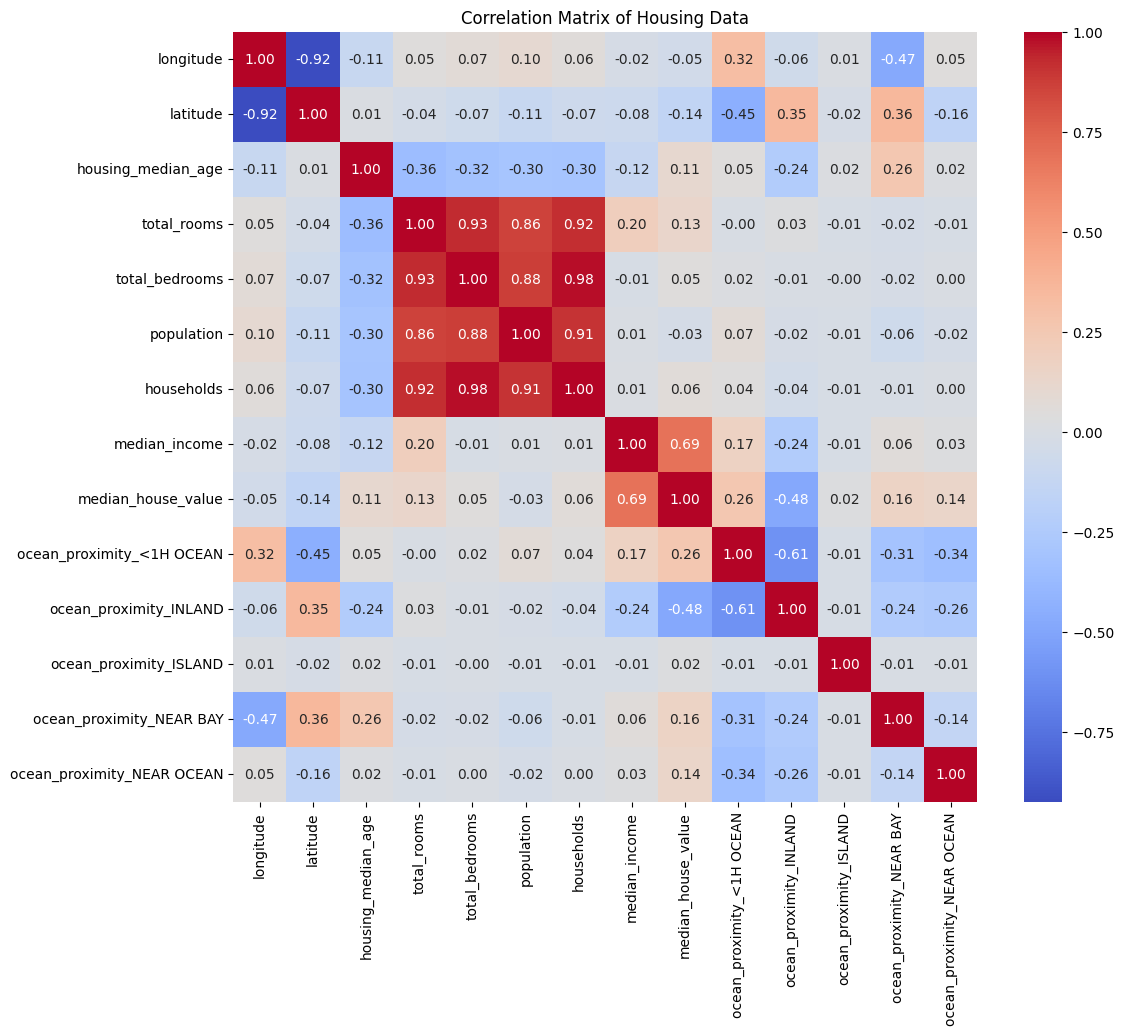

In [6]:
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Housing Data')
plt.show()


A variável com maior correlação positiva com a variável target é a "median_income". Essa correlação sugere que quanto mais o "median_income" aumenta, o "median_house_value" também tende a aumentar.

### 3. Separe os dados em validação e teste

In [7]:
# Define features (X) and target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (14303, 13)
Shape of X_test: (6130, 13)
Shape of y_train: (14303,)
Shape of y_test: (6130,)


### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [8]:
# Train a Decision Tree Regressor with max_depth = 8
tree_depth_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_depth_8.fit(X_train, y_train)

# Train a Decision Tree Regressor with max_depth = 2
tree_depth_2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_depth_2.fit(X_train, y_train)

print("Decision Tree Regressors trained successfully.")

Decision Tree Regressors trained successfully.


### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

In [9]:
from sklearn.metrics import mean_squared_error

# Predictions for tree_depth_8
y_train_pred_8 = tree_depth_8.predict(X_train)
y_test_pred_8 = tree_depth_8.predict(X_test)

# Calculate MSE for tree_depth_8
mse_train_8 = mean_squared_error(y_train, y_train_pred_8)
mse_test_8 = mean_squared_error(y_test, y_test_pred_8)

print(f"Tree with max_depth=8 - Training MSE: {mse_train_8:,.0f}")
print(f"Tree with max_depth=8 - Testing MSE: {mse_test_8:,.0f}\n")

# Predictions for tree_depth_2
y_train_pred_2 = tree_depth_2.predict(X_train)
y_test_pred_2 = tree_depth_2.predict(X_test)

# Calculate MSE for tree_depth_2
mse_train_2 = mean_squared_error(y_train, y_train_pred_2)
mse_test_2 = mean_squared_error(y_test, y_test_pred_2)

print(f"Tree with max_depth=2 - Training MSE: {mse_train_2:,.0f}")
print(f"Tree with max_depth=2 - Testing MSE: {mse_test_2:,.0f}")

Tree with max_depth=8 - Training MSE: 3,155,880,404
Tree with max_depth=8 - Testing MSE: 3,941,659,635

Tree with max_depth=2 - Training MSE: 6,712,935,749
Tree with max_depth=2 - Testing MSE: 6,785,906,662


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

A árvore de maior profundidade (8) apresenta uma diferença significativa entre o MSE de treinamento e o de teste sugere algum grau de Overfitting.

A árvore menos profunda (2), tem valores de MSE mais próximos, embora os valores sejam muito mais altos, sugerindo que ela esteja sub-ajustado (underfitting).

Do jeito que estão, a árvore mais profunda parece mais adequada. Apesar do overfitting, ela demonstra capacidade preditiva maior nos dados de teste (evidenciado pelo MSE significativamente menor).

### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

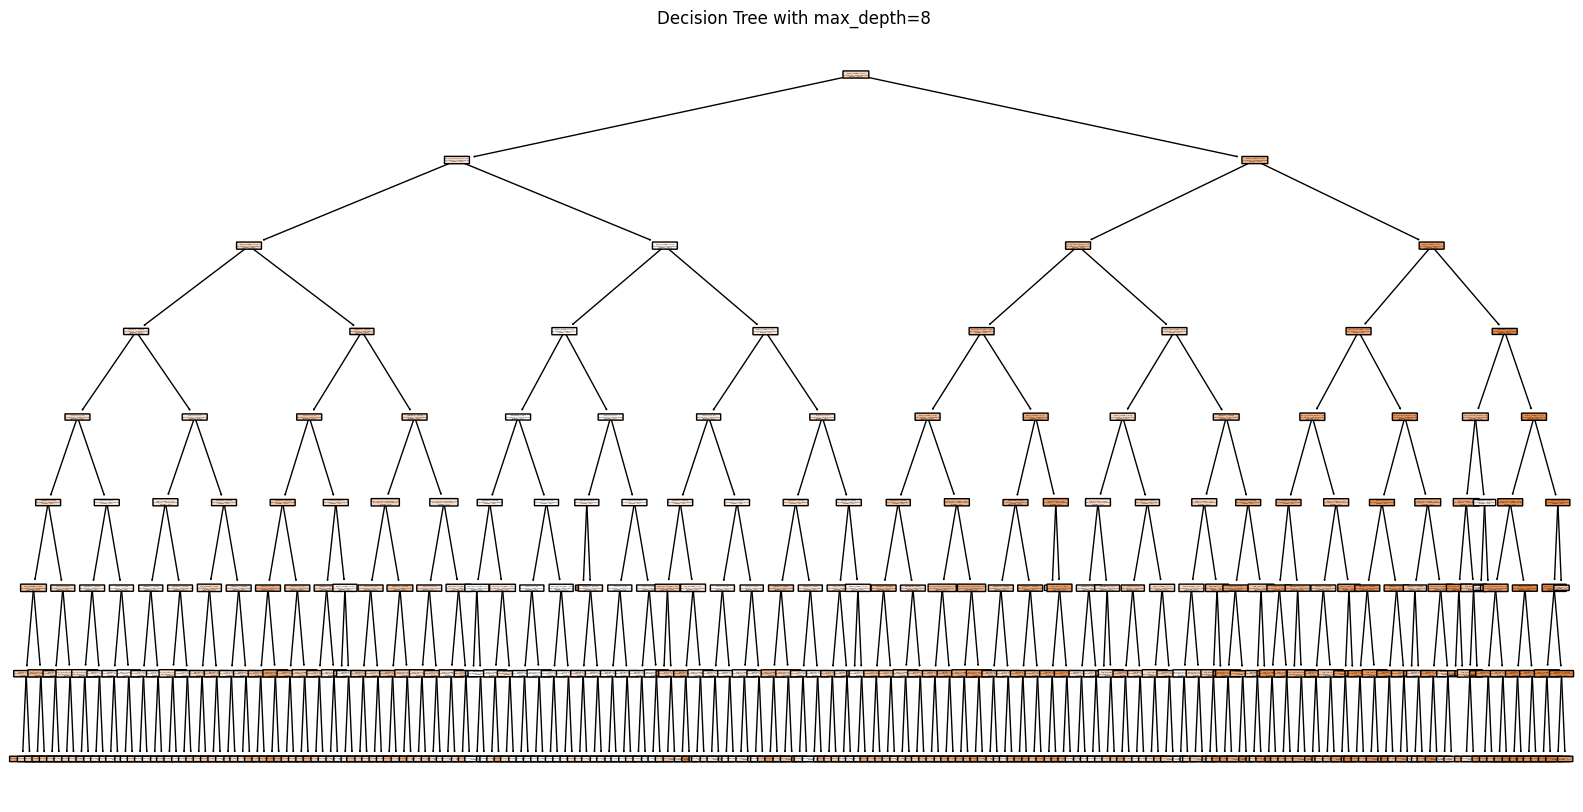

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(tree_depth_8, feature_names=X_train.columns.tolist(), filled=True, proportion=True, rounded=True)
plt.title('Decision Tree with max_depth=8')
plt.show()

A visualização acima mostra a árvore de decisão com profundidade máxima de 8. Cada nó na árvore representa uma decisão baseada em uma característica (feature) e um valor limite.

*   **`feature <= value`**: A condição de divisão para aquele nó.
*   **`mse`**: O Mean Squared Error (MSE) dos dados naquele nó. Um MSE menor indica que os valores alvo são mais homogêneos.
*   **`samples`**: O número de amostras (dados) que se encontram naquele nó.
*   **`value`**: O valor médio da variável alvo (`median_house_value`) para as amostras naquele nó.
*   **`filled`**: A cor de cada nó indica a classe de saída (para classificação) ou o valor médio (para regressão, como neste caso).

Observando a árvore, você pode identificar as variáveis que aparecem mais próximas à raiz como as mais "importantes" no processo de tomada de decisão da árvore. A primeira divisão é sempre feita na característica que melhor reduz o MSE.

In [11]:
import pandas as pd

# Get feature importances from the tree_depth_8 model
feature_importances = tree_depth_8.feature_importances_

# Get the feature names from X_train columns
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances for Decision Tree (max_depth=8):")
display(importance_df)

Feature Importances for Decision Tree (max_depth=8):


,Feature,Importance
7,median_income,0.590245
9,ocean_proximity_INLAND,0.186281
0,longitude,0.087450
1,latitude,0.081309
2,housing_median_age,0.026908
12,ocean_proximity_NEAR OCEAN,0.008419
5,population,0.006314
6,households,0.005235
4,total_bedrooms,0.004304
3,total_rooms,0.001722


A tabela acima mostra a **importância de cada característica (feature)** para o modelo de árvore de decisão com `max_depth=8`.

*   **Importância da Característica**: Indica a contribuição relativa de cada feature para a redução da impureza (neste caso, MSE) na árvore de decisão. Quanto maior o valor, mais 'importante' a feature é para as divisões da árvore e, consequentemente, para as previsões do modelo.

*   **Como Interpretar**: As características no topo da lista (com valores de importância maiores) são as que o modelo utilizou com mais frequência e de forma mais significativa para tomar decisões ao longo de sua estrutura. Isso significa que essas features têm um papel mais proeminente na determinação do `median_house_value`.